In [3319]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline 


In [3320]:
df=pd.read_csv("mubwab_data_copy.csv")

In [3321]:
df.head(3)

,ad_id,title,link,image_url,scraped_at,location,price,property_type,property_condition,property_age,...,has_microwave,has_mountain_view,has_oven,has_parabolic_antenna,has_sea_view,has_security,has_storage_room,has_washing_machine,amenities_entre-seul,amenities_façade_extérieure
0,8038583,Appartement en vente à La Soukra,https://www.mubawab.tn/fr/pa/8038583/apparteme...,https://www.mubawab-media.com/ad/8/038/583F/h/...,2025-03-30T16:47:18.752488,"La Soukra, La Soukra",NaN,Appartement,NaN,Moins d'un an,...,0,0,1,0,0,1,0,0,0,0
1,8036651,Superbe appartement à vendre à Ain Zaghouan No...,https://www.mubawab.tn/fr/pa/8036651/superbe-a...,https://www.mubawab-media.com/ad/8/036/651F/h/...,2025-03-30T16:47:20.726346,"Ain Zaghouan Nord, La Marsa",552000.0,Appartement,NaN,NaN,...,0,0,0,1,0,1,1,0,0,0
2,7881341,Jolie Appartement à vendre,https://www.mubawab.tn/fr/pa/7881341/jolie-app...,https://www.mubawab-media.com/ad/7/881/341F/h/...,2025-03-30T16:47:23.178884,"Les Jardins de Carthage, Le Kram",590000.0,Appartement,NaN,Moins d'un an,...,1,0,1,1,0,1,0,0,0,1


In [3322]:
column_to_drop=["ad_id","title","link","image_url","scraped_at","floor_level","orientation","floor_material","property_condition","property_standing","delivery_date"]
df=df.drop(columns=column_to_drop)

In [3323]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8256 entries, 0 to 8255
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     8256 non-null   object 
 1   price                        6663 non-null   float64
 2   property_type                8256 non-null   object 
 3   property_age                 3403 non-null   object 
 4   construction_status          7344 non-null   object 
 5   area_sqm                     8154 non-null   float64
 6   total_rooms                  7115 non-null   float64
 7   bedrooms                     7603 non-null   float64
 8   bathrooms                    7385 non-null   float64
 9   has_garden                   8256 non-null   int64  
 10  has_terrace                  8256 non-null   int64  
 11  has_garage                   8256 non-null   int64  
 12  has_elevator                 8256 non-null   int64  
 13  has_pool          

In [3324]:
df.shape

(8256, 34)

In [3325]:
df.head(1)

,location,price,property_type,property_age,construction_status,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,...,has_microwave,has_mountain_view,has_oven,has_parabolic_antenna,has_sea_view,has_security,has_storage_room,has_washing_machine,amenities_entre-seul,amenities_façade_extérieure
0,"La Soukra, La Soukra",NaN,Appartement,Moins d'un an,En cours de construction,93.0,2.0,1.0,1.0,1,...,0,0,1,0,0,1,0,0,0,0


In [3326]:
 df.isnull().sum()

location                          0
price                          1593
property_type                     0
property_age                   4853
construction_status             912
area_sqm                        102
total_rooms                    1141
bedrooms                        653
bathrooms                       871
has_garden                        0
has_terrace                       0
has_garage                        0
has_elevator                      0
has_pool                          0
has_air_conditioning              0
has_heating                       0
has_equipped_kitchen              0
has_armored_door                  0
has_concierge                     0
has_double_glazing                0
has_european_living_room          0
has_fireplace                     0
has_fridge                        0
has_furniture                     0
has_microwave                     0
has_mountain_view                 0
has_oven                          0
has_parabolic_antenna       

## delete null values of prices

In [3328]:
df = df.dropna(subset=['price'])

In [3329]:
df.shape

(6663, 34)

## Price Statistics:

In [3331]:
df['price'].describe()

count    6.663000e+03
mean     1.595152e+06
std      2.422461e+07
min      6.500000e+03
25%      3.190000e+05
50%      5.000000e+05
75%      8.500000e+05
max      1.250000e+09
Name: price, dtype: float64

## check if there 're negative price

In [3333]:
len(df[df['price'] < 0])

0

In [3334]:
df['property_type'].unique()

array(['Appartement', 'Villa', 'Ferme', 'Maison'], dtype=object)

In [3335]:
df[df['property_type'] == 'Ferme']


,location,price,property_type,property_age,construction_status,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,...,has_microwave,has_mountain_view,has_oven,has_parabolic_antenna,has_sea_view,has_security,has_storage_room,has_washing_machine,amenities_entre-seul,amenities_façade_extérieure
55,"Tebourba, Tebourba",1150000.0,Ferme,NaN,NaN,65000.0,NaN,NaN,NaN,0,...,0,0,0,0,0,0,1,0,0,0
113,"Borj El Amri, Borj El Amri",875000.0,Ferme,NaN,NaN,14370.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
418,"Kalaa Essghira, Kalâa Sghira",365000.0,Ferme,NaN,NaN,6461.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
520,"Menzel Bouzelfa, Menzel Bouzelfa",360000.0,Ferme,NaN,NaN,12000.0,NaN,1.0,NaN,0,...,0,0,0,0,0,0,1,0,0,0
638,"El Maamoura, Beni Khiar",650000.0,Ferme,NaN,NaN,4000.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
703,"Sidi Thabet, Sidi Thabet",5800000.0,Ferme,NaN,NaN,100000.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
857,"Cap Zebib, Ras Jebel",1300000.0,Ferme,NaN,NaN,4800.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
953,"Sidi Saad, Mornag",5500000.0,Ferme,NaN,NaN,20000.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,1,0,0,0
1079,"Ain Zaghouan Nord, La Marsa",498000.0,Ferme,NaN,NaN,125.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,0,0,0,0
1393,"Cité Ennasr 2, Ariana Ville",385000.0,Ferme,NaN,NaN,165.0,NaN,NaN,NaN,0,...,0,0,0,0,0,1,0,0,0,0


## No Need for "Ferme" Type

In [3337]:
df.drop(df[df['property_type'] == 'Ferme'].index, inplace=True)

In [3338]:
df['property_type'].unique()

array(['Appartement', 'Villa', 'Maison'], dtype=object)

In [3339]:
df['property_type'].value_counts()


property_type
Appartement    3539
Villa          2126
Maison          951
Name: count, dtype: int64

if you're doing  a label encoding approach where:

Appartement = 1
Villa = 2
Maison = 3
 this approach is simpler than one-hot encoding, but it has a potential drawback: it introduces an ordinal relationship between the property types that doesn't naturally exist. The model might interpret Villa (2) as being "better than" or "more than" Appartement (1), or that Maison (3) is "better than" or "more than" Villa (2).
This artificial ordering could bias your model's predictions. Property types are categorical variables without inherent numerical ordering.

In [3341]:
temp_encoded = pd.get_dummies(df['property_type'], prefix='property_type')

# Remove the original property_type column
df = df.drop('property_type', axis=1)

# Add the encoded columns to df
df = pd.concat([df, temp_encoded], axis=1)

# Convert encoded columns to int
encoded_columns = [col for col in df.columns if 'property_type_' in col]
df[encoded_columns] = df[encoded_columns].astype(int)

In [3342]:
df.tail(2)

,location,price,property_age,construction_status,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,...,has_parabolic_antenna,has_sea_view,has_security,has_storage_room,has_washing_machine,amenities_entre-seul,amenities_façade_extérieure,property_type_Appartement,property_type_Maison,property_type_Villa
8254,"Hammamet, Hammamet",2000000.0,NaN,NaN,700.0,NaN,NaN,3.0,1,1,...,0,0,0,0,0,0,0,0,0,1
8255,"El Menzah 9, El Menzah",1500000.0,NaN,Nouveau,600.0,7.0,6.0,3.0,1,0,...,1,0,0,1,0,0,0,0,0,1


In [3343]:
df.columns.tolist()

['location',
 'price',
 'property_age',
 'construction_status',
 'area_sqm',
 'total_rooms',
 'bedrooms',
 'bathrooms',
 'has_garden',
 'has_terrace',
 'has_garage',
 'has_elevator',
 'has_pool',
 'has_air_conditioning',
 'has_heating',
 'has_equipped_kitchen',
 'has_armored_door',
 'has_concierge',
 'has_double_glazing',
 'has_european_living_room',
 'has_fireplace',
 'has_fridge',
 'has_furniture',
 'has_microwave',
 'has_mountain_view',
 'has_oven',
 'has_parabolic_antenna',
 'has_sea_view',
 'has_security',
 'has_storage_room',
 'has_washing_machine',
 'amenities_entre-seul',
 'amenities_façade_extérieure',
 'property_type_Appartement',
 'property_type_Maison',
 'property_type_Villa']

In [3344]:
df['property_age'].unique()

array([nan, "Moins d'un an", '10-20 ans', '1-5 ans', '5-10 ans',
       '30-50 ans', '20-30 ans', 'Plus de 100 ans', '50-70 ans',
       '70-100 ans'], dtype=object)

In [3345]:
df.groupby('property_age')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
property_age,,,,,,,,
1-5 ans,618.0,1.435975e+06,1.461452e+07,70000.0,330000.0,520000.0,850000.0,350000000.0
10-20 ans,397.0,2.671559e+06,2.868005e+07,10000.0,285000.0,445000.0,950000.0,520000000.0
20-30 ans,132.0,1.018833e+06,1.757125e+06,65000.0,250000.0,620000.0,1200000.0,16000000.0
30-50 ans,48.0,8.274521e+05,8.071961e+05,70000.0,244275.0,670000.0,1125000.0,4500000.0
5-10 ans,432.0,7.276642e+05,8.757139e+05,6600.0,290000.0,449500.0,803890.0,9000000.0
50-70 ans,15.0,8.043333e+05,5.959472e+05,125000.0,425000.0,750000.0,990000.0,2500000.0
70-100 ans,8.0,6.775000e+05,9.098194e+05,220000.0,292500.0,327500.0,456250.0,2900000.0
Moins d'un an,930.0,2.473167e+06,3.614101e+07,11210.0,328500.0,483000.0,750000.0,900000000.0
Plus de 100 ans,9.0,1.250556e+06,9.604571e+05,135000.0,420000.0,990000.0,1700000.0,2900000.0


In [3346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6616 non-null   object 
 1   price                        6616 non-null   float64
 2   property_age                 2589 non-null   object 
 3   construction_status          5831 non-null   object 
 4   area_sqm                     6558 non-null   float64
 5   total_rooms                  5700 non-null   float64
 6   bedrooms                     6045 non-null   float64
 7   bathrooms                    5865 non-null   float64
 8   has_garden                   6616 non-null   int64  
 9   has_terrace                  6616 non-null   int64  
 10  has_garage                   6616 non-null   int64  
 11  has_elevator                 6616 non-null   int64  
 12  has_pool                     6616 non-null   int64  
 13  has_air_conditioning   

# For Linear regression it's better to use "ordinal encoding "

In [3348]:
# Create mapping for age categories in order
age_mapping = {
    "Moins d'un an": 1,
    "1-5 ans": 2,
    "5-10 ans": 3,
    "10-20 ans": 4,
    "20-30 ans": 5,
    "30-50 ans": 6,
    "50-70 ans": 7,
    "70-100 ans": 8,
    "Plus de 100 ans": 9
}
# Create a missing indicator
df['property_age_missing'] = df['property_age'].isna().astype(int)

# Fill missing values with a placeholder
df['property_age_filled'] = df['property_age'].fillna("Unknown")

# Map to ordinal values
age_mapping["Unknown"] = 0  # or -1 to distinguish it
df['property_age_ordinal'] = df['property_age_filled'].map(age_mapping)
df
df['property_age_ordinal'].value_counts().sort_index()

property_age_ordinal
0    4027
1     930
2     618
3     432
4     397
5     132
6      48
7      15
8       8
9       9
Name: count, dtype: int64

In [3349]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6616 non-null   object 
 1   price                        6616 non-null   float64
 2   property_age                 2589 non-null   object 
 3   construction_status          5831 non-null   object 
 4   area_sqm                     6558 non-null   float64
 5   total_rooms                  5700 non-null   float64
 6   bedrooms                     6045 non-null   float64
 7   bathrooms                    5865 non-null   float64
 8   has_garden                   6616 non-null   int64  
 9   has_terrace                  6616 non-null   int64  
 10  has_garage                   6616 non-null   int64  
 11  has_elevator                 6616 non-null   int64  
 12  has_pool                     6616 non-null   int64  
 13  has_air_conditioning   

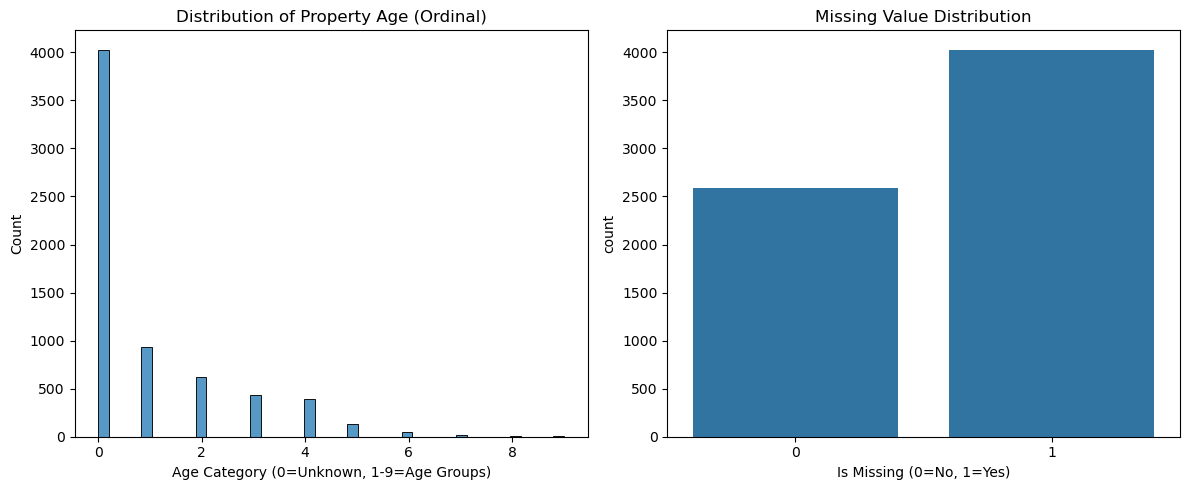

In [3350]:
# Cell 5: Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Ordinal values distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='property_age_ordinal')
plt.title('Distribution of Property Age (Ordinal)')
plt.xlabel('Age Category (0=Unknown, 1-9=Age Groups)')

# Plot 2: Missing value indicator
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='property_age_missing')
plt.title('Missing Value Distribution')
plt.xlabel('Is Missing (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# When preparing features for modeling
X = df[['property_age_ordinal', 'property_age_missing', 'other_features...']].copy()
# Note that property_age and property_age_filled are not included in X

For tree-based models, you can actually use the original categorical variable with missing values as a separate category:

In [3353]:
# Create one-hot encoding with better naming
df_encoded = pd.get_dummies(df['property_age'], prefix='age', dummy_na=True)
df_encoded = df_encoded.astype(int)

# Rename columns to be more consistent and clean
new_names = {
    'age_1-5 ans': 'age_1_5',
    'age_5-10 ans': 'age_5_10',
    'age_10-20 ans': 'age_10_20',
    'age_20-30 ans': 'age_20_30',
    'age_30-50 ans': 'age_30_50',
    'age_50-70 ans': 'age_50_70',
    'age_70-100 ans': 'age_70_100',
    "age_Moins d'un an": 'age_less_1',
    'age_Plus de 100 ans': 'age_over_100',
    'age_nan': 'age_missing'
}

df_encoded = df_encoded.rename(columns=new_names)

# Create df_tree without redundant columns
df_tree = df.drop(['property_age', 'property_age_ordinal', 'property_age_missing'], axis=1)
df_tree = pd.concat([df_tree, df_encoded], axis=1)
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6616 non-null   object 
 1   price                        6616 non-null   float64
 2   construction_status          5831 non-null   object 
 3   area_sqm                     6558 non-null   float64
 4   total_rooms                  5700 non-null   float64
 5   bedrooms                     6045 non-null   float64
 6   bathrooms                    5865 non-null   float64
 7   has_garden                   6616 non-null   int64  
 8   has_terrace                  6616 non-null   int64  
 9   has_garage                   6616 non-null   int64  
 10  has_elevator                 6616 non-null   int64  
 11  has_pool                     6616 non-null   int64  
 12  has_air_conditioning         6616 non-null   int64  
 13  has_heating            

In [3354]:
df_tree['age_1_5'].value_counts().sort_index()


age_1_5
0    5998
1     618
Name: count, dtype: int64

In [3355]:
c=["property_age","property_age_filled"]
df=df.drop(columns=c)

In [3356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6616 non-null   object 
 1   price                        6616 non-null   float64
 2   construction_status          5831 non-null   object 
 3   area_sqm                     6558 non-null   float64
 4   total_rooms                  5700 non-null   float64
 5   bedrooms                     6045 non-null   float64
 6   bathrooms                    5865 non-null   float64
 7   has_garden                   6616 non-null   int64  
 8   has_terrace                  6616 non-null   int64  
 9   has_garage                   6616 non-null   int64  
 10  has_elevator                 6616 non-null   int64  
 11  has_pool                     6616 non-null   int64  
 12  has_air_conditioning         6616 non-null   int64  
 13  has_heating            

In [3357]:
df["construction_status"].unique()

array(['Finalisé', 'En cours de construction', nan, 'Nouveau', 'Bon état',
       'À rénover'], dtype=object)

In [3358]:
df_tree['construction_status'].value_counts().sort_index()


construction_status
Bon état                    2716
En cours de construction     221
Finalisé                      96
Nouveau                     2635
À rénover                    163
Name: count, dtype: int64

In [3359]:
df['construction_status'].isnull().sum()

785

Handling Missing Values

 I didn't recommend ordinal encoding for linear regression because of how linear models interpret numerical values.
Ordinal encoding (like label encoding) assigns arbitrary numeric values to categories (e.g., "Bon état" = 0, "En cours de construction" = 1, etc.). For linear regression, this creates an implicit mathematical relationship between categories that likely doesn't exist in reality.
Consider what happens in linear regression:

If "Bon état" = 0 and "En cours de construction" = 1, the model will interpret "En cours de construction" as being "one unit greater" than "Bon état"
The model would assume "Finalisé" = 2 is twice as impactful as "En cours de construction" = 1
This numeric ordering implies a clear hierarchy or progression between categories

This is problematic because:

Your construction status categories ("Bon état", "Nouveau", "À rénover", etc.) likely don't have this kind of mathematical relationship
Linear regression will literally multiply these arbitrary numbers by coefficients
The results will be biased by the arbitrary numeric assignments

One-hot encoding solves this by creating binary indicators for each category, allowing the model to learn independent coefficients for each status type without imposing a numerical relationship between them.
Tree-based models (Random Forest, XGBoost) don't have this limitation because they make splits based on values rather than treating them as continuous numeric features, which is why ordinal/label encoding works well for them.
Would you like me to add ordinal encoding to the linear regression approach anyway? It's technically possible but generally not recommended for the reasons I've explained.

In [3362]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# For linear regression models (df)
# ================================
# Create a copy of the construction_status column before modifying
df['construction_status_original'] = df['construction_status']

# Mark missing values
df['missing_status'] = df['construction_status'].isna().astype(int)

# Fill missing values with a new category
df['construction_status'] = df['construction_status'].fillna('Missing')

# One-hot encode with better column names
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['construction_status']])

# Create cleaner column names
# The first category is dropped (usually 'Bon état' if alphabetical order), so we start from the second
categories = encoder.categories_[0][1:]  # Gets all categories except the first one
clean_names = []

for category in categories:
    # Clean up the category name
    if category == 'En cours de construction':
        clean_name = 'en_construction'
    elif category == 'Finalisé':
        clean_name = 'finalise'
    elif category == 'Missing':
        clean_name = 'missing'
    elif category == 'Nouveau':
        clean_name = 'nouveau'
    elif category == 'À rénover':
        clean_name = 'a_renover'
    elif category == 'Bon état':
        clean_name = 'bon_etat'
    else:
        # Handle any other categories by removing spaces and special characters
        clean_name = category.lower().replace(' ', '_').replace('à', 'a').replace('é', 'e')
    
    clean_names.append(f'status_{clean_name}')

# Create dataframe with clean names
encoded_df = pd.DataFrame(encoded, columns=clean_names, index=df.index)

# Combine with original dataframe
df = pd.concat([df, encoded_df], axis=1)

# Remove the original construction_status column as it's now encoded
df.drop('construction_status', axis=1, inplace=True)


# For tree-based models (df_tree)
# ===============================
# Create a copy of the construction_status column before modifying
df_tree['construction_status_original'] = df_tree['construction_status']

# For tree models, we can simply use label encoding
df_tree['construction_status'] = df_tree['construction_status'].fillna('Missing')
label_encoder = LabelEncoder()
df_tree['construction_status'] = label_encoder.fit_transform(df_tree['construction_status'])

# No need for the missing indicator as trees can handle this information directly
# No need for one-hot encoding either, as trees work well with label encoding

# Keep track of the mapping for interpretability if needed
status_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Construction status mapping for tree models:", status_mapping)

Construction status mapping for tree models: {'Bon état': 0, 'En cours de construction': 1, 'Finalisé': 2, 'Missing': 3, 'Nouveau': 4, 'À rénover': 5}


In [3363]:
df_tree.head()

,location,price,construction_status,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,...,age_10_20,age_20_30,age_30_50,age_5_10,age_50_70,age_70_100,age_less_1,age_over_100,age_missing,construction_status_original
1,"Ain Zaghouan Nord, La Marsa",552000.0,2,132.0,3.0,2.0,2.0,1,0,1,...,0,0,0,0,0,0,0,0,1,Finalisé
2,"Les Jardins de Carthage, Le Kram",590000.0,1,123.0,2.0,2.0,2.0,0,0,0,...,0,0,0,0,0,0,1,0,0,En cours de construction
3,"Cité el Ghazela, Raoued",390000.0,1,140.0,4.0,3.0,2.0,0,1,0,...,0,0,0,0,0,0,0,0,1,En cours de construction
5,"Ain Zaghouan Nord, La Marsa",400000.0,1,122.0,3.0,2.0,2.0,1,1,0,...,0,0,0,0,0,0,1,0,0,En cours de construction
7,"Sidi Hassine, Sidi Hassine",194150.0,2,120.0,3.0,2.0,1.0,1,0,0,...,0,0,0,0,0,0,0,0,1,Finalisé


In [3364]:
df_tree['construction_status'].unique()

array([2, 1, 3, 4, 0, 5])

In [3365]:
df_tree=df_tree.drop(columns="construction_status_original")

In [3366]:
df_tree

,location,price,construction_status,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,...,age_1_5,age_10_20,age_20_30,age_30_50,age_5_10,age_50_70,age_70_100,age_less_1,age_over_100,age_missing
1,"Ain Zaghouan Nord, La Marsa",552000.0,2,132.0,3.0,2.0,2.0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
2,"Les Jardins de Carthage, Le Kram",590000.0,1,123.0,2.0,2.0,2.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,"Cité el Ghazela, Raoued",390000.0,1,140.0,4.0,3.0,2.0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
5,"Ain Zaghouan Nord, La Marsa",400000.0,1,122.0,3.0,2.0,2.0,1,1,0,...,0,0,0,0,0,0,0,1,0,0
7,"Sidi Hassine, Sidi Hassine",194150.0,2,120.0,3.0,2.0,1.0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8249,"Cité Ennasr 2, Ariana Ville",690000.0,0,186.0,4.0,3.0,2.0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
8250,"La Marsa, La Marsa",1600000.0,0,300.0,6.0,5.0,4.0,1,1,1,...,0,0,0,0,0,0,0,0,0,1
8253,"Borj Cedria, Hammam Chatt",580000.0,4,630.0,10.0,8.0,3.0,1,1,1,...,1,0,0,0,0,0,0,0,0,0
8254,"Hammamet, Hammamet",2000000.0,3,700.0,NaN,NaN,3.0,1,1,1,...,0,0,0,0,0,0,0,0,0,1


In [3367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   location                      6616 non-null   object 
 1   price                         6616 non-null   float64
 2   area_sqm                      6558 non-null   float64
 3   total_rooms                   5700 non-null   float64
 4   bedrooms                      6045 non-null   float64
 5   bathrooms                     5865 non-null   float64
 6   has_garden                    6616 non-null   int64  
 7   has_terrace                   6616 non-null   int64  
 8   has_garage                    6616 non-null   int64  
 9   has_elevator                  6616 non-null   int64  
 10  has_pool                      6616 non-null   int64  
 11  has_air_conditioning          6616 non-null   int64  
 12  has_heating                   6616 non-null   int64  
 13  has_equi

In [3368]:
df=df.drop(columns="construction_status_original")

In [3369]:
df

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
1,"Ain Zaghouan Nord, La Marsa",552000.0,132.0,3.0,2.0,2.0,1,0,1,1,...,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0
2,"Les Jardins de Carthage, Le Kram",590000.0,123.0,2.0,2.0,2.0,0,0,0,1,...,0,0,0,1,0,1.0,0.0,0.0,0.0,0.0
3,"Cité el Ghazela, Raoued",390000.0,140.0,4.0,3.0,2.0,0,1,0,1,...,0,0,1,0,0,1.0,0.0,0.0,0.0,0.0
5,"Ain Zaghouan Nord, La Marsa",400000.0,122.0,3.0,2.0,2.0,1,1,0,1,...,0,0,0,1,0,1.0,0.0,0.0,0.0,0.0
7,"Sidi Hassine, Sidi Hassine",194150.0,120.0,3.0,2.0,1.0,1,0,0,1,...,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8249,"Cité Ennasr 2, Ariana Ville",690000.0,186.0,4.0,3.0,2.0,0,1,1,1,...,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0
8250,"La Marsa, La Marsa",1600000.0,300.0,6.0,5.0,4.0,1,1,1,0,...,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0
8253,"Borj Cedria, Hammam Chatt",580000.0,630.0,10.0,8.0,3.0,1,1,1,0,...,0,1,0,2,0,0.0,0.0,0.0,1.0,0.0
8254,"Hammamet, Hammamet",2000000.0,700.0,NaN,NaN,3.0,1,1,1,0,...,0,1,1,0,1,0.0,0.0,1.0,0.0,0.0


In [3370]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 1 to 8255
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6616 non-null   object 
 1   price                        6616 non-null   float64
 2   area_sqm                     6558 non-null   float64
 3   total_rooms                  5700 non-null   float64
 4   bedrooms                     6045 non-null   float64
 5   bathrooms                    5865 non-null   float64
 6   has_garden                   6616 non-null   int64  
 7   has_terrace                  6616 non-null   int64  
 8   has_garage                   6616 non-null   int64  
 9   has_elevator                 6616 non-null   int64  
 10  has_pool                     6616 non-null   int64  
 11  has_air_conditioning         6616 non-null   int64  
 12  has_heating                  6616 non-null   int64  
 13  has_equipped_kitchen   

In [3371]:
df_tree.dropna(subset=['area_sqm'], inplace=True)
df.dropna(subset=['area_sqm'], inplace=True)


In [3372]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6558 entries, 1 to 8255
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   location                     6558 non-null   object 
 1   price                        6558 non-null   float64
 2   area_sqm                     6558 non-null   float64
 3   total_rooms                  5648 non-null   float64
 4   bedrooms                     5988 non-null   float64
 5   bathrooms                    5811 non-null   float64
 6   has_garden                   6558 non-null   int64  
 7   has_terrace                  6558 non-null   int64  
 8   has_garage                   6558 non-null   int64  
 9   has_elevator                 6558 non-null   int64  
 10  has_pool                     6558 non-null   int64  
 11  has_air_conditioning         6558 non-null   int64  
 12  has_heating                  6558 non-null   int64  
 13  has_equipped_kitchen   

In [3373]:
df['bedrooms'].unique()

array([  2.,   3.,  nan,   4.,   6.,   1.,  11.,   5.,   7.,   9.,   8.,
        20.,  10.,  12.,  16.,  15.,  13., 100.,  14.,  19.,  18.,  21.,
        24.])

In [3374]:
df['bedrooms'].describe()

count    5988.000000
mean        3.326319
std         2.247890
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       100.000000
Name: bedrooms, dtype: float64

In [3375]:
df['bathrooms'].describe()

count    5811.000000
mean        2.074686
std         1.276801
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: bathrooms, dtype: float64

In [3376]:
df['bathrooms'].unique()

array([ 2.,  1.,  3., nan,  4., 10.,  6.,  8.,  5.,  7., 12., 15.,  9.,
       11.])

In [3377]:
 df[df['bathrooms'] == 15]


,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
1244,"La Marsa, La Marsa",4150000.0,1000.0,18.0,16.0,15.0,1,1,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0


In [3378]:
 df[df['bathrooms'] == 10]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
177,"Cité El Wafa, Nabeul",1300000.0,391.0,12.0,11.0,10.0,1,1,1,0,...,0,1,0,2,0,0.0,0.0,0.0,0.0,0.0
688,"Ksour Essef, Ksour Essef",1500000.0,2923.0,4.0,20.0,10.0,0,0,0,1,...,0,0,1,0,0,0.0,0.0,0.0,1.0,0.0
1262,"Aouina, La Marsa",4000000.0,999.0,16.0,15.0,10.0,1,1,1,1,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
3354,"Hammamet Nord, Hammamet",2100000.0,850.0,10.0,20.0,10.0,0,1,1,0,...,0,0,0,3,0,0.0,0.0,0.0,0.0,0.0
5122,"Raoued, Raoued",1500000.0,365.0,23.0,19.0,10.0,0,1,0,0,...,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0
5418,"Hammam El Ghezaz, Hammam Ghezèze",3000000.0,1275.0,35.0,21.0,10.0,1,1,1,0,...,0,1,0,3,0,0.0,0.0,0.0,0.0,0.0
6002,"Djerba, Djerba",2150000.0,2610.0,14.0,14.0,10.0,1,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
6405,"Kélibia, Kélibia",1250000.0,530.0,10.0,10.0,10.0,1,1,1,0,...,0,1,0,3,0,0.0,0.0,0.0,0.0,0.0
7606,"Hergla, Hergla",720000.0,450.0,10.0,7.0,10.0,0,1,1,0,...,0,0,1,0,0,0.0,0.0,0.0,1.0,0.0
7680,"Cité de la Plage, Hammam Sousse",1500000.0,720.0,16.0,10.0,10.0,1,0,0,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0


In [3379]:
df_tree['bathrooms'].isna().sum()

747

In [3380]:
df['bathrooms'] = df['bathrooms'].fillna(1)
df_tree['bathrooms'] = df_tree['bathrooms'].fillna(1)

In [3381]:
df_tree['bathrooms'].isna().sum()

0

In [3382]:
df_tree['bathrooms'].unique()

array([ 2.,  1.,  3.,  4., 10.,  6.,  8.,  5.,  7., 12., 15.,  9., 11.])

In [3383]:
df['bedrooms'].isna().sum()

570

In [3384]:
df['area_sqm'].isna().sum()

0

In [3385]:
df.shape

(6558, 42)

In [3386]:
df['bedrooms'].describe()

count    5988.000000
mean        3.326319
std         2.247890
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max       100.000000
Name: bedrooms, dtype: float64

In [3387]:
df[df['bedrooms']==100]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
4135,"El Gourjani, Tunis",660000.0,667.0,6.0,100.0,1.0,1,1,1,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,1.0


In [3388]:
df.loc[df['bedrooms'] == 100, 'bedrooms'] = 4
df_tree.loc[df_tree['bedrooms'] == 100, 'bedrooms'] = 4


In [3389]:
df['bedrooms'].describe()
df['bedrooms'].unique()

array([ 2.,  3., nan,  4.,  6.,  1., 11.,  5.,  7.,  9.,  8., 20., 10.,
       12., 16., 15., 13., 14., 19., 18., 21., 24.])

In [3390]:

df_tree.loc[df_tree['bedrooms'] == 18, 'bathrooms'] = 3
df.loc[df['bedrooms'] == 18, 'bathrooms'] = 3
df_tree.loc[df_tree['bedrooms'] == 9, 'total_rooms'] = 15
df.loc[df['bedrooms'] == 18, 'total_rooms'] = 15
df.loc[df['bedrooms'] == 18, 'bedrooms'] = 9
df_tree.loc[df['bedrooms'] == 18, 'bedrooms'] = 9


In [3391]:
df[df['bedrooms'] == 9]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
370,"Sidi Bousaid, Carthage",1400000.0,205.0,9.0,9.0,1.0,0,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,1.0,0.0
611,"Les Jardins de Carthage, Le Kram",240000000.0,570.0,9.0,9.0,3.0,1,0,1,0,...,1,0,0,4,0,0.0,0.0,0.0,0.0,0.0
949,"Le Kram, Le Kram",1150000.0,210.0,12.0,9.0,3.0,1,0,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
1001,"La Marsa, La Marsa",1500000.0,510.0,10.0,9.0,4.0,1,1,0,0,...,0,0,1,0,0,0.0,0.0,0.0,0.0,0.0
1240,"El Menzah 6, Ariana Ville",2800000.0,702.0,10.0,9.0,3.0,1,1,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
1275,"Cité El Hana, La Marsa",1300000.0,600.0,12.0,9.0,7.0,1,1,1,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
1971,Sidi Abdelhamid,550000.0,375.0,12.0,9.0,6.0,1,1,1,0,...,0,1,0,3,0,0.0,0.0,0.0,0.0,0.0
2104,"La Médina, La Medina",420000.0,441.0,11.0,9.0,3.0,0,1,0,0,...,1,0,0,9,0,0.0,0.0,0.0,0.0,1.0
2135,"Hammam Lif, Hammam Lif",470000.0,150.0,10.0,9.0,7.0,0,1,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
2237,"Ain Zaghouan Sud, La Marsa",1500000.0,600.0,9.0,9.0,4.0,0,0,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0


In [3392]:
df['bedrooms'].unique()

array([ 2.,  3., nan,  4.,  6.,  1., 11.,  5.,  7.,  9.,  8., 20., 10.,
       12., 16., 15., 13., 14., 19., 21., 24.])

In [3393]:
df[df['bedrooms'] == 14 ]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
4596,"Mezraya, Houmt Souk",2500000.0,1100.0,14.0,14.0,9.0,0,0,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
5036,"Raf Raf, Raf Raf",700000.0,538.0,NaN,14.0,5.0,1,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
5449,"Gammarth, La Marsa",990000.0,142.0,22.0,14.0,8.0,0,0,0,0,...,0,0,0,2,0,0.0,0.0,0.0,0.0,0.0
6002,"Djerba, Djerba",2150000.0,2610.0,14.0,14.0,10.0,1,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
8014,"Riadh al Andalous, Ariana Ville",1125000.0,617.0,NaN,14.0,3.0,1,1,1,0,...,0,1,0,3,0,0.0,0.0,0.0,1.0,0.0


In [3394]:
df.loc[(df['bedrooms'] == 14) & (df['area_sqm'] == 538), 'total_rooms'] = 32
df_tree.loc[(df_tree['bedrooms'] == 14) & (df_tree['area_sqm'] == 538), 'total_rooms'] = 32

In [3395]:
df[df['bedrooms'] == 14 ]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
4596,"Mezraya, Houmt Souk",2500000.0,1100.0,14.0,14.0,9.0,0,0,1,0,...,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0
5036,"Raf Raf, Raf Raf",700000.0,538.0,32.0,14.0,5.0,1,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
5449,"Gammarth, La Marsa",990000.0,142.0,22.0,14.0,8.0,0,0,0,0,...,0,0,0,2,0,0.0,0.0,0.0,0.0,0.0
6002,"Djerba, Djerba",2150000.0,2610.0,14.0,14.0,10.0,1,1,0,0,...,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0
8014,"Riadh al Andalous, Ariana Ville",1125000.0,617.0,NaN,14.0,3.0,1,1,1,0,...,0,1,0,3,0,0.0,0.0,0.0,1.0,0.0


In [3396]:
df['total_rooms'].isna().sum()

908

In [3397]:
df['bedrooms'].isna().sum()

570

In [3398]:
# Drop rows where "bedrooms" is NaN
df.dropna(subset=['bedrooms'], inplace=True)
df_tree.dropna(subset=['bedrooms'], inplace=True)

In [3399]:
df['bedrooms'].isna().sum()

0

In [3400]:
df.loc[df['total_rooms'].isna(), 'total_rooms'] = df['bedrooms'] + df['bathrooms'] + 1 + 1
df_tree['total_rooms'] = df_tree['bedrooms'] + df_tree['bathrooms'] + 1 + 1


In [3401]:
df['total_rooms'].isna().sum()

0

In [3402]:
df.head()

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,property_type_Maison,property_type_Villa,property_age_missing,property_age_ordinal,missing_status,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover
1,"Ain Zaghouan Nord, La Marsa",552000.0,132.0,3.0,2.0,2.0,1,0,1,1,...,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0
2,"Les Jardins de Carthage, Le Kram",590000.0,123.0,2.0,2.0,2.0,0,0,0,1,...,0,0,0,1,0,1.0,0.0,0.0,0.0,0.0
3,"Cité el Ghazela, Raoued",390000.0,140.0,4.0,3.0,2.0,0,1,0,1,...,0,0,1,0,0,1.0,0.0,0.0,0.0,0.0
5,"Ain Zaghouan Nord, La Marsa",400000.0,122.0,3.0,2.0,2.0,1,1,0,1,...,0,0,0,1,0,1.0,0.0,0.0,0.0,0.0
7,"Sidi Hassine, Sidi Hassine",194150.0,120.0,3.0,2.0,1.0,1,0,0,1,...,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0


In [3403]:
df["location"].unique()

array(['Ain Zaghouan Nord, La Marsa', 'Les Jardins de Carthage, Le Kram',
       'Cité el Ghazela, Raoued', 'Sidi Hassine, Sidi Hassine',
       'Khezama Est, Khezama Est', 'Hammamet, Hammamet',
       'Rades Foret, Rades', 'Nouvelle Medina, Nouvelle Medina',
       'La Soukra, La Soukra', 'El Mourouj 6, El Mourouj',
       'Gammarth, La Marsa', 'Fouchana, Fouchana', 'Bizerte, Bizerte',
       'Ouzra, Mornag', 'La Marsa, La Marsa', 'Aouina, La Marsa',
       'Chotrana 1, La Soukra', 'El Yasminette, Nouvelle Medina',
       'Radès, Rades', 'La Manouba, La Manouba',
       'Cité Bou Mhel, Boumhel Bassatine', 'Ezzahra, Ezzahra',
       'El Manar 1, El Menzah', 'Cité El Wafa, Nabeul',
       'Hammamet Nord, Hammamet', 'Sfax Ville', 'Fouchana',
       'Korba, Korba', 'Nabeul, Nabeul', 'Beni Khiar, Beni Khiar',
       'Sfax Ville, Sfax Ville', 'Sahloul, Sousse Jaouhara',
       'Hammam Sousse, Hammam Sousse', 'Hammamet', 'Bizerte',
       'Kélibia, Kélibia', 'Djerba, Djerba', 'Hammamet Sud, 

In [3404]:
import pandas as pd
import numpy as np

# =============================================
# 1. COMPREHENSIVE DELEGATION-TO-CITY MAPPING
# =============================================
DELEGATION_TO_CITY = {
    # Tunis Governorate
    'La Marsa': 'Tunis', 'Le Kram': 'Tunis', 'Carthage': 'Tunis',
    'Bab Bhar': 'Tunis', 'Bab Souika': 'Tunis', 'El Omrane': 'Tunis',
    'Ettadhamen': 'Tunis', 'Ezzouhour': 'Tunis', 'La Goulette': 'Tunis',
    'Le Bardo': 'Tunis', 'Nouvelle Medina': 'Tunis', 'Montplaisir': 'Tunis',
    'Montfleury': 'Tunis', 'Bab Saadoun': 'Tunis', 'Bab El Khadra': 'Tunis',
    'El Halfaouine': 'Tunis', 'Cité El Khadra': 'Tunis', 'Ettahrir': 'Tunis',
    'El Agba': 'Tunis', 'République': 'Tunis', 'Maakel Ezzaim': 'Tunis',
    'Hedi Chaker': 'Tunis', 'El Gourjani': 'Tunis', 'Habib Thameur': 'Tunis',
    'Sijoumi': 'Tunis', 'Bab Jazira': 'Tunis', 'Bab El Falla': 'Tunis',
    'Cité Ibn Khaldoun': 'Tunis', 'Cité Hached': 'Tunis', 'Cité Ubn Khaldoun': 'Tunis',
    'Cité Presidentielle': 'Tunis', 'Cité Tarek Ibn Zied': 'Tunis', 'El Omrane Superieur': 'Tunis',
    
    # Ariana Governorate
    'Raoued': 'Ariana', 'La Soukra': 'Ariana', 'Ariana Ville': 'Ariana',
    'Sidi Thabet': 'Ariana', 'Mnihla': 'Ariana', 'Ennasr': 'Ariana',
    
    # Manouba Governorate
    'La Manouba': 'La Manouba', 'Douar Hicher': 'La Manouba',
    'Oued Ellil': 'La Manouba', 'Mornaguia': 'La Manouba',
    'Tebourba': 'La Manouba', 'Denden': 'La Manouba', 'Sidi Abdelhamid': 'La Manouba',
    
    # Ben Arous Governorate
    'Fouchana': 'Ben Arous', 'Rades': 'Ben Arous', 'Mornag': 'Ben Arous',
    'Ezzahra': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous',
    'Hammam Chott': 'Ben Arous', 'Mohamedia': 'Ben Arous', 'Mégrine': 'Ben Arous',
    'Bou Mhel El Bassatine': 'Ben Arous', 'Borj Cedria': 'Ben Arous',
    'Cité Olympique': 'Ben Arous', 'Ben Arous Sud': 'Ben Arous',
    'Cité Plein Air': 'Ben Arous', 'Cité El Mouna': 'Ben Arous',
    'Boumhel Bassatine': 'Ben Arous', 'Cité Ennarjes 1': 'Ben Arous',
    
    # Sousse Governorate
    'Sousse': 'Sousse', 'Sousse Ville': 'Sousse', 'Sousse Jaouhara': 'Sousse',
    'Hammam Sousse': 'Sousse', 'Akouda': 'Sousse', 'Kalaa Kebira': 'Sousse',
    'Kalaa Seghira': 'Sousse', 'Khezama Est': 'Sousse', 'Khezama Ouest': 'Sousse',
    'Sahloul': 'Sousse', 'Chott Meriem': 'Sousse', 'Hergla': 'Sousse',
    'El Kantaoui': 'Sousse', 'Bouhssina': 'Sousse', 'Msaken': 'Sousse',
    'Kalâa Sghira': 'Sousse', 'Skanes': 'Sousse', 'Enfidha': 'Sousse',
    'Cité Jaouhara': 'Sousse', 'Cité Frina': 'Sousse',
    
    # Nabeul Governorate
    'Hammamet': 'Nabeul', 'Nabeul': 'Nabeul', 'Kélibia': 'Nabeul',
    'Korba': 'Nabeul', 'Soliman': 'Nabeul', 'Dar Châabane': 'Nabeul',
    'Beni Khiar': 'Nabeul', 'Bou Argoub': 'Nabeul', 'El Haouaria': 'Nabeul',
    'Hammam El Ghezaz': 'Nabeul', 'Grombalia': 'Nabeul', 'Menzel Temime': 'Nabeul',
    'Tazarka': 'Nabeul', 'Barraket Essahel': 'Nabeul',
    
    # Other Governorates
    'Sfax': 'Sfax', 'Bizerte': 'Bizerte', 'Mahdia': 'Mahdia',
    'Monastir': 'Monastir', 'Gabès': 'Gabès', 'Medenine': 'Medenine',
    'Beja': 'Beja', 'Jendouba': 'Jendouba', 'Kairouan': 'Kairouan',
    'Kasserine': 'Kasserine', 'Gafsa': 'Gafsa', 'Tozeur': 'Tozeur',
    'Kebili': 'Kebili', 'Tataouine': 'Tataouine', 'Siliana': 'Siliana',
    'Zaghouan': 'Zaghouan', 'Sidi Bouzid': 'Sidi Bouzid'
}

# =============================================
# 2. LOCATION PROCESSING FUNCTIONS
# =============================================
def extract_location_info(location):
    if pd.isna(location):
        return pd.Series({'neighborhood': None, 'delegation': None, 'city': None})
    
    location = str(location).strip().title()
    
    # Handle special cases
    special_cases = {
        'Cap Zebib, Ras Jebel': ('Cap Zebib', 'Ras Jebel', 'Bizerte'),
        'Bou Mhel, Boumhel Bassatine': ('Bou Mhel', 'Boumhel Bassatine', 'Ben Arous'),
        'Cité Bou Mhel, Boumhel Bassatine': ('Cité Bou Mhel', 'Boumhel Bassatine', 'Ben Arous'),
        'El Yasminette, Nouvelle Medina': ('El Yasminette', 'Nouvelle Medina', 'Tunis')
    }
    
    if location in special_cases:
        neighborhood, delegation, city = special_cases[location]
        return pd.Series({
            'neighborhood': neighborhood,
            'delegation': delegation,
            'city': city
        })
    
    # Handle repetitive patterns
    if ',' in location:
        parts = [p.strip() for p in location.split(',')]
        if len(parts) == 2 and parts[0] == parts[1]:
            location = parts[0]
    
    # Find best matching delegation
    for delegation in sorted(DELEGATION_TO_CITY.keys(), key=len, reverse=True):
        if delegation in location:
            neighborhood = location.replace(delegation, '').strip(' ,-')
            return pd.Series({
                'neighborhood': neighborhood if neighborhood else None,
                'delegation': delegation,
                'city': DELEGATION_TO_CITY[delegation]
            })
    
    # Final fallback
    return pd.Series({
        'neighborhood': location if location else None,
        'delegation': None,
        'city': None
    })

def clean_neighborhood(name):
    if pd.isna(name):
        return None
    
    name = str(name).strip().title()
    
    # Remove prefixes
    prefixes = ["Cité ", "El ", "La ", "Les ", "Ain ", "Bab ", "Hammam ",
               "Route ", "Zone ", "Centre "]
    for prefix in prefixes:
        if name.startswith(prefix):
            name = name[len(prefix):].strip()
    
    # Standardize names
    replacements = {
        "Bou Mhel": "Boumhel",
        "Bouhssina": "Bouhsina",
        "Kélibia": "Kelibia",
        "Médiouni": "Mediouni",
        "Ubn": "Ibn"
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    
    return name if name else None

# =============================================
# 3. MAIN PROCESSING FUNCTION
# =============================================
def process_dataframe(df):
    # Make a copy to avoid warnings
    df = df.copy()
    
    # Extract location components
    location_data = df['location'].apply(extract_location_info)
    
    # Add new columns
    df['neighborhood'] = location_data['neighborhood']
    df['delegation'] = location_data['delegation']
    df['city'] = location_data['city']
    
    # Clean neighborhood names
    df['neighborhood'] = df['neighborhood'].apply(clean_neighborhood)
    
    # Fill missing data
    df['city'] = df.apply(
        lambda row: row['city'] if pd.notna(row['city']) 
        else DELEGATION_TO_CITY.get(row['delegation']),
        axis=1
    )
    
    df['delegation'] = df.apply(
        lambda row: row['delegation'] if pd.notna(row['delegation'])
        else 'Unknown' if pd.isna(row['city'])
        else row['city'] + ' Area',
        axis=1
    )
    
    # Add combined address
    df['full_address'] = df.apply(
        lambda row: f"{row['neighborhood']}, {row['delegation']}, {row['city']}" 
        if pd.notna(row['neighborhood']) 
        else f"{row['delegation']}, {row['city']}",
        axis=1
    )
    
    # Add cleanliness flag
    df['location_clean'] = ~df['delegation'].str.contains('Unknown|Area')
    
    # Fill remaining NAs
    df['neighborhood'] = df['neighborhood'].fillna("Not Specified")
    df['delegation'] = df['delegation'].fillna("Unknown")
    df['city'] = df['city'].fillna("Unknown")
    
    return df

# =============================================
# 4. PROCESS BOTH DATAFRAMES
# =============================================
# Process main dataframe
df = process_dataframe(df)

# Process tree dataframe
df_tree = process_dataframe(df_tree)

# Verify the new columns
print("New columns in df:", [col for col in df.columns if col not in ['location']])
print("New columns in df_tree:", [col for col in df_tree.columns if col not in ['location']])

# Sample output
print("\nSample processed data from df:")
print(df[['location', 'neighborhood', 'delegation', 'city', 'full_address', 'location_clean']].head())

print("\nSample processed data from df_tree:")
print(df_tree[['location', 'neighborhood', 'delegation', 'city', 'full_address', 'location_clean']].head())

New columns in df: ['price', 'area_sqm', 'total_rooms', 'bedrooms', 'bathrooms', 'has_garden', 'has_terrace', 'has_garage', 'has_elevator', 'has_pool', 'has_air_conditioning', 'has_heating', 'has_equipped_kitchen', 'has_armored_door', 'has_concierge', 'has_double_glazing', 'has_european_living_room', 'has_fireplace', 'has_fridge', 'has_furniture', 'has_microwave', 'has_mountain_view', 'has_oven', 'has_parabolic_antenna', 'has_sea_view', 'has_security', 'has_storage_room', 'has_washing_machine', 'amenities_entre-seul', 'amenities_façade_extérieure', 'property_type_Appartement', 'property_type_Maison', 'property_type_Villa', 'property_age_missing', 'property_age_ordinal', 'missing_status', 'status_en_construction', 'status_finalise', 'status_missing', 'status_nouveau', 'status_a_renover', 'neighborhood', 'delegation', 'city', 'full_address', 'location_clean']
New columns in df_tree: ['price', 'construction_status', 'area_sqm', 'total_rooms', 'bedrooms', 'bathrooms', 'has_garden', 'has_te

In [3405]:
df.head()

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover,neighborhood,delegation,city,full_address,location_clean
1,"Ain Zaghouan Nord, La Marsa",552000.0,132.0,3.0,2.0,2.0,1,0,1,1,...,0.0,1.0,0.0,0.0,0.0,Zaghouan Nord,La Marsa,Tunis,"Zaghouan Nord, La Marsa, Tunis",True
2,"Les Jardins de Carthage, Le Kram",590000.0,123.0,2.0,2.0,2.0,0,0,0,1,...,1.0,0.0,0.0,0.0,0.0,"Jardins De , Le Kram",Carthage,Tunis,"Jardins De , Le Kram, Carthage, Tunis",True
3,"Cité el Ghazela, Raoued",390000.0,140.0,4.0,3.0,2.0,0,1,0,1,...,1.0,0.0,0.0,0.0,0.0,Ghazela,Raoued,Ariana,"Ghazela, Raoued, Ariana",True
5,"Ain Zaghouan Nord, La Marsa",400000.0,122.0,3.0,2.0,2.0,1,1,0,1,...,1.0,0.0,0.0,0.0,0.0,Zaghouan Nord,La Marsa,Tunis,"Zaghouan Nord, La Marsa, Tunis",True
7,"Sidi Hassine, Sidi Hassine",194150.0,120.0,3.0,2.0,1.0,1,0,0,1,...,0.0,1.0,0.0,0.0,0.0,Sidi Hassine,Unknown,Unknown,"Sidi Hassine, Unknown, None",False


In [3406]:
df["neighborhood"].unique()

array(['Zaghouan Nord', 'Jardins De , Le Kram', 'Ghazela', 'Sidi Hassine',
       'Not Specified', 'Foret', '6', 'Gammarth', 'Ouzra', 'Aouina',
       'Chotrana 1', 'Yasminette', 'Radès', 'Boumhel',
       'Manar 1, El Menzah', 'Wafa', 'Nord', 'Ville', 'Sahloul', 'Djerba',
       'Sud', 'Rejiche', 'Sers', 'Ariana', 'Berges Du Lac 2', 'Amilcar',
       'Sidi Bousaid', 'Denden', 'Sidi Daoued', 'Yasmine', 'Akouda',
       'Touristique,  Ville', 'Kantaoui', 'Chotrana 2', 'Pins',
       'Neapolis', 'Menzah 9, El Menzah', 'Bouhsina', 'Bhar Lazreg',
       'Ennasr 1', 'Mongi Slim', 'Corniche', 'Ennasr 2', 'Zarzouna',
       'Chatt', '2', 'Menzah', 'Ksour Essef', 'Midoun Zone Touristique',
       'Erriadh', 'Mutuelle Ville, El Menzah', 'Manar 2, El Menzah',
       'Sahline', 'Chotrana 3', 'Tantana', 'Caravelles, El Menzah',
       'Sidi El Mahrsi', 'Borj Louzir', 'Marsa Erriadh', 'Du Stade',
       'Gammarth Village', 'Ain', 'Menzah 5', 'Nouvelle Ariana',
       'Midoune, Midoun', 'Sousse Riad

In [3407]:
df["delegation"].unique()

array(['La Marsa', 'Carthage', 'Raoued', 'Unknown', 'Khezama Est',
       'Hammamet', 'Rades', 'Nouvelle Medina', 'La Soukra', 'El Mourouj',
       'Fouchana', 'Bizerte', 'Mornag', 'La Manouba', 'Boumhel Bassatine',
       'Ezzahra', 'Nabeul', 'Sfax', 'Korba', 'Beni Khiar',
       'Sousse Jaouhara', 'Hammam Sousse', 'Kélibia', 'Ariana Ville',
       'El Haouaria', 'Sidi Thabet', 'Sousse Ville', 'Chott Meriem',
       'Mahdia', 'Khezama Ouest', 'Hergla', 'Hammam El Ghezaz', 'Sousse',
       'Borj Cedria', 'Soliman', 'Dar Châabane', 'Ezzouhour', 'Mnihla',
       'Akouda', 'Cité Ennarjes 1', 'Zaghouan', 'Le Kram', 'Ettahrir',
       'Douar Hicher', 'Kalâa Sghira', 'Menzel Temime', 'Cité El Khadra',
       'Le Bardo', 'Cité Jaouhara', 'République', 'Ras Jebel',
       'La Goulette', 'Hammam Lif', 'Tozeur', 'Mégrine', 'Bab Saadoun',
       'Mornaguia', 'Oued Ellil', 'Bab Bhar', 'Maakel Ezzaim',
       'Sidi Abdelhamid', 'Monastir', 'Montplaisir', 'Cité Frina',
       'El Agba', 'Tazarka', '

In [3408]:
df["city"].unique()

array(['Tunis', 'Ariana', 'Unknown', 'Sousse', 'Nabeul', 'Ben Arous',
       'Bizerte', 'La Manouba', 'Sfax', 'Mahdia', 'Zaghouan', 'Tozeur',
       'Monastir', 'Gabès', 'Beja', 'Gafsa', 'Jendouba'], dtype=object)

In [3409]:
df[df["city"]=="Unknown"]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover,neighborhood,delegation,city,full_address,location_clean
7,"Sidi Hassine, Sidi Hassine",194150.0,120.0,3.0,2.0,1.0,1,0,0,1,...,0.0,1.0,0.0,0.0,0.0,Sidi Hassine,Unknown,Unknown,"Sidi Hassine, Unknown, None",False
46,"Sidi Hassine, Sidi Hassine",182071.0,112.0,4.0,3.0,1.0,1,0,0,1,...,0.0,1.0,0.0,0.0,0.0,Sidi Hassine,Unknown,Unknown,"Sidi Hassine, Unknown, None",False
47,"Sidi Hassine, Sidi Hassine",194150.0,120.0,3.0,2.0,1.0,1,0,0,1,...,0.0,1.0,0.0,0.0,0.0,Sidi Hassine,Unknown,Unknown,"Sidi Hassine, Unknown, None",False
64,"Sidi Hassine, Sidi Hassine",127629.0,79.0,3.0,2.0,1.0,1,0,0,0,...,0.0,1.0,0.0,0.0,0.0,Sidi Hassine,Unknown,Unknown,"Sidi Hassine, Unknown, None",False
146,"El Manar 1, El Menzah",330000.0,120.0,4.0,3.0,2.0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,"Manar 1, El Menzah",Unknown,Unknown,"Manar 1, El Menzah, Unknown, None",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8219,"Tunis, Tunis",1450000.0,300.0,6.0,3.0,1.0,0,1,1,0,...,0.0,0.0,1.0,0.0,0.0,Tunis,Unknown,Unknown,"Tunis, Unknown, None",False
8221,"El Aouina, El Aouina",560000.0,180.0,6.0,3.0,1.0,0,1,0,0,...,0.0,0.0,1.0,0.0,0.0,Aouina,Unknown,Unknown,"Aouina, Unknown, None",False
8232,"Aghir, Aghir",850000.0,750.0,3.0,4.0,1.0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,Aghir,Unknown,Unknown,"Aghir, Unknown, None",False
8242,"Djerba, Djerba",140000.0,140.0,5.0,3.0,3.0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,Djerba,Unknown,Unknown,"Djerba, Unknown, None",False


In [3410]:
df[df["city"] == "Unknown"]["location"].tolist()

['Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'El Manar 1, El Menzah',
 'Djerba, Djerba',
 'Djerba, Djerba',
 'Rejiche, Rejiche',
 'Sers, Sers',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Sidi Hassine, Sidi Hassine',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'Djerba',
 'El Manar 1, El Menzah',
 'El Menzah 9, El Menzah',
 'El Manar 1, El Menzah',
 'El Menzah 9, El Menzah',
 'Zarzouna',
 'Djerba, Djerba',
 'El Manar 1, El Menzah',
 'Cité El Menzah',
 'Ksour Essef, Ksour Essef',
 'Midoun zone touristique, Midoun zone touristique',
 'Mutuelle Ville, El Menzah',
 'El Manar 2, El Menzah',
 'Djerba, Djerba',
 'Sahline, Sahline',
 'Cité Caravelles, El Menzah',
 'El Menzah 9, El Menzah',
 'El Manar 1, El 

In [3411]:
df[df["city"].isna()]

,location,price,area_sqm,total_rooms,bedrooms,bathrooms,has_garden,has_terrace,has_garage,has_elevator,...,status_en_construction,status_finalise,status_missing,status_nouveau,status_a_renover,neighborhood,delegation,city,full_address,location_clean


In [3412]:
locations_for_missing_cities = df[df["city"].isna()]["location"].tolist()
locations_for_missing_cities

[]

In [3413]:
df_tree["city"].unique()

array(['Tunis', 'Ariana', 'Unknown', 'Sousse', 'Nabeul', 'Ben Arous',
       'Bizerte', 'La Manouba', 'Sfax', 'Mahdia', 'Zaghouan', 'Tozeur',
       'Monastir', 'Gabès', 'Beja', 'Gafsa', 'Jendouba'], dtype=object)

In [3414]:
 df[df["city"] == "Unknown"].shape[1]

47

In [3415]:
#df = df[df["city"] != "Unknown"]


In [3416]:
df["city"].unique()

array(['Tunis', 'Ariana', 'Unknown', 'Sousse', 'Nabeul', 'Ben Arous',
       'Bizerte', 'La Manouba', 'Sfax', 'Mahdia', 'Zaghouan', 'Tozeur',
       'Monastir', 'Gabès', 'Beja', 'Gafsa', 'Jendouba'], dtype=object)

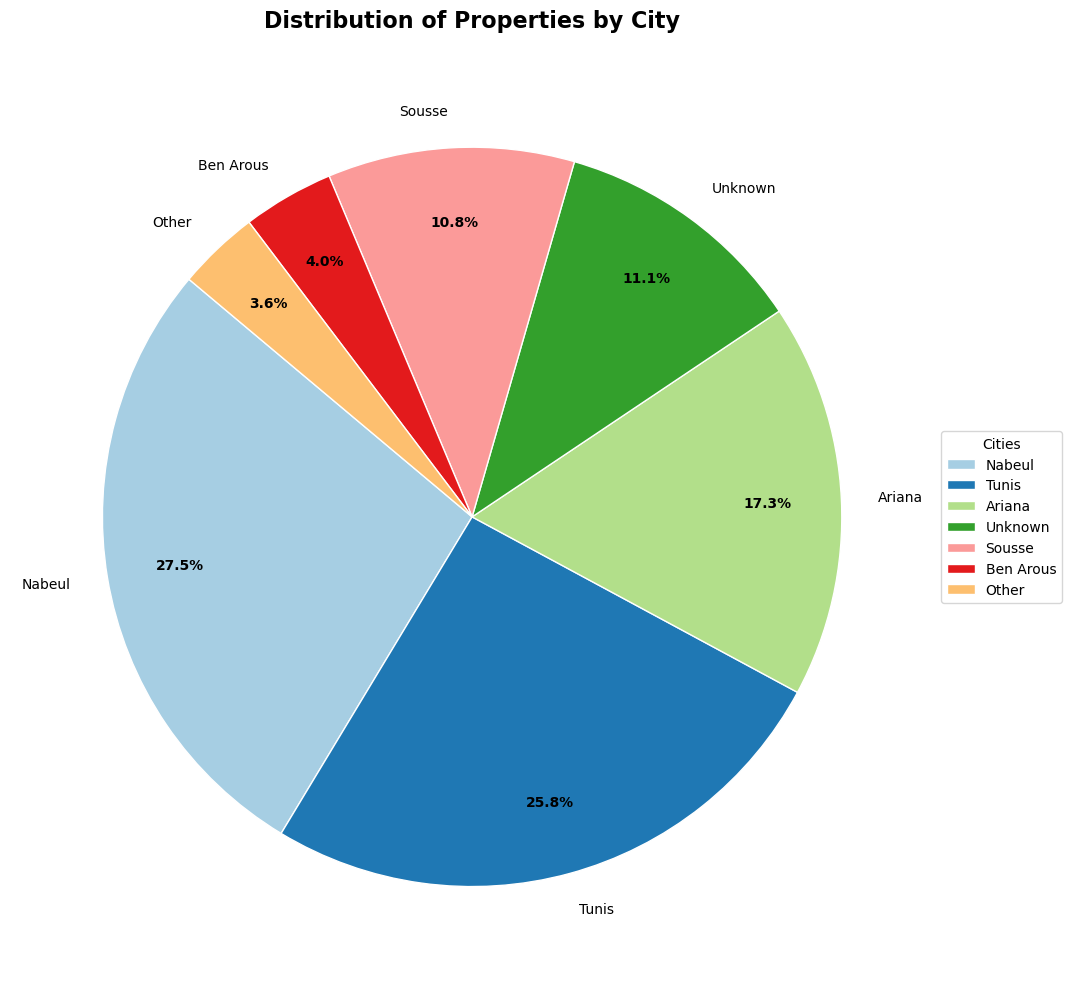

In [3417]:
import matplotlib.pyplot as plt

# 1. Prepare the data - group small slices into "Other"
city_counts = df['city'].value_counts()
threshold = 0.02  # 2% threshold
small_cities = city_counts[city_counts/city_counts.sum() < threshold]
if len(small_cities) > 0:
    city_counts = city_counts[city_counts/city_counts.sum() >= threshold]
    city_counts['Other'] = small_cities.sum()

# 2. Create the figure
plt.figure(figsize=(12, 10))

# 3. Create the pie chart with better styling
patches, texts, autotexts = plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    textprops={'fontsize': 12},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=plt.cm.Paired.colors
)

# 4. Improve label readability
plt.setp(autotexts, size=10, weight="bold")
plt.setp(texts, size=10)

# 5. Add legend and title
plt.legend(
    patches,
    city_counts.index,
    title='Cities',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.title('Distribution of Properties by City', pad=20, fontsize=16, fontweight='bold')

# 6. Show the plot
plt.tight_layout()
plt.show()